# Init

In [1]:
import os, pickle
from random import choice
from collections import deque

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
_DATA_DRIVE = "DATA_TANK"

tests = [
    "KC-KP",
    "SC-KP",
    "KC-SP",
    "SC-SP",
]

In [3]:
########## SETUP ###################################################################################
_JSON_PATH  = "data/allData.txt"
_DATA_DRIVE = "DATA_TANK"
# _PLOT_DIR   = "/media/james/FILEPILE/EROM/data/plots/"
_PLOT_DIR   = "data/plots/"

tests = [
    "KC-KP",
    "SC-KP",
    "KC-SP",
    "SC-SP",
]

longTestNames = [
    "Known Class & Known Pose", 
    "Sensed Class & Known Pose", 
    "Known Class & Sensed Pose", 
    "Sensed Class & Sensed Pose", 
]

# paths = [ f"/media/james/{_DATA_DRIVE}/2025-08_{test}" for test in tests ]
datasets = [
    [ f"/media/james/{_DATA_DRIVE}/2025-08B_{test}" for test in tests ],
    [ f"/media/james/{_DATA_DRIVE}/RWB_2025-09_{test}" for test in tests ],
]

dataLabels = ["RGB", "RBW",]
datNamLong = {
    "RGB": "Red-Green-Blue", 
    "RBW": "Red-Black-White",
}

fNames = [ f"{_PLOT_DIR}{test}" for test in tests  ]

plotExt = ".pdf"

pkls = deque()

for iii, paths in enumerate( datasets ):
    setNam = dataLabels[iii]
    suffix = "_" + setNam
    skip   = False

    for ii, test in enumerate( tests ):
        ##### Init ################################################################
        path     = paths[ii]
        fName    = fNames[ii]
        longTNam = longTestNames[ii]

        ##### Load ################################################################
        try:
            pkls.extend( [os.path.join( path, item ) for item in os.listdir( path ) if ".pkl" in f"{item}".lower()] )
        except FileNotFoundError as e:
            print( f"\n404, SKIP THIS TEST: {e}\n" )
            skip = True
            continue

# "Ground Truth" Annotator

In [4]:
from State import OCV_State_Tracker
ocvTracker = OCV_State_Tracker()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


# Load File(s)

In [5]:
_EXP_INDEX = 0 # 130

In [6]:
print( f"Found {len(pkls)} files!" ) 
pklFile = pkls[ _EXP_INDEX ]

data = list()
try:
    with open( pklFile, 'rb' ) as f:
        data = pickle.load( f )
        print( f"LOAD SUCCESS: {pklFile}" )
except EOFError as e:
    print( f"LOAD ERROR: {e}" )

Found 162 files!
LOAD SUCCESS: /media/james/DATA_TANK/2025-08B_KC-KP/EROM-Memories_08-25-2025_11-18-58.pkl


['query', 'abbrv', 'image', 'depth', 't']
0.0
Block mask of 17780 points!
Block mask is 0.1869456171989441 away!
Span is [169, 167]
Arc is [np.float64(0.23760718511178358), np.float64(0.19127717771075356)]
Scale is [1.1157 0.8967]
Block mask of 44 points!
MASK FOUND!


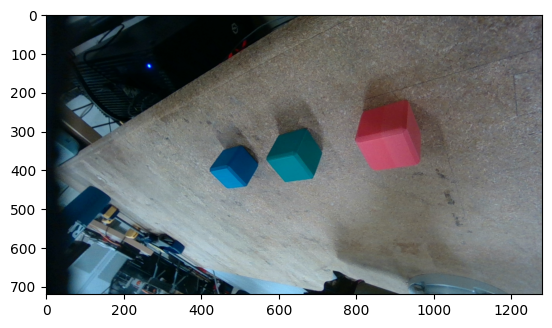

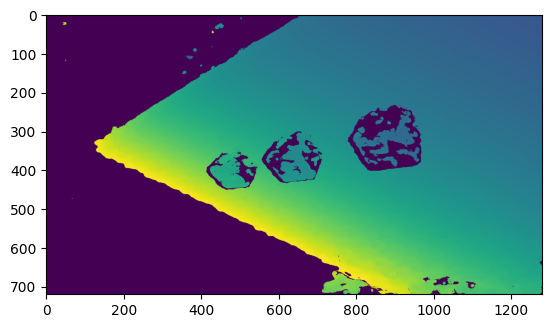

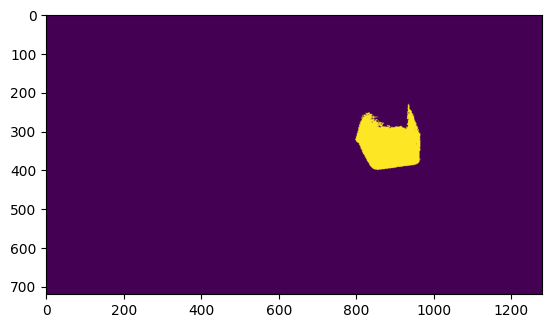

In [7]:
for i, datum in enumerate( data ):
    tMsg  = datum['msg']
    tData = datum['data']
    if tMsg == "ObsMeta":
        inpt = tData['input']
        hits = tData['hits']
        snap = inpt[ choice( list( inpt.keys() ) ) ]
        print( list( snap.keys() ) )
        imag = snap['image']
        dpth = snap['depth']
        plt.figure()
        plt.imshow( imag )
        plt.figure()
        plt.imshow( dpth )

        # ocvTracker.TEST_FUNC( 'redBlock', imag )
        res = ocvTracker.find_block_mask( 'redBlock', imag, dpth )
        if res is not None:
            print( "MASK FOUND!" )
            plt.figure()
            plt.imshow( res )
        
        break